# Laboratorio 4 - Modelación: Regresión

## Base de datos: Seguro médico

En este laboratorio se desarrolla un pipeline completo de modelado para un problema de regresión.  
La base de datos contiene información de personas aseguradas y el valor de los cargos médicos asociados.

El objetivo es construir y comparar diferentes modelos de regresión para predecir el valor de los cargos médicos.

## 0. Problema

In [3]:
# ======================= #
# 1. LIBRERÍAS GENERALES  #
# ======================= #

import pandas as pd
import numpy as np
import sqlite3
import os

In [4]:
import sqlite3
import pandas as pd
import os

# ================================= #
# RUTA COMPLETA DE LA BASE          #
# ================================= #

db_path = "C:/Users/Lenovo ThinkBook/Downloads/ml-project_analitica_datos/data/database/datos.db"
# ================================= #
# VERIFICAR EXISTENCIA              #
# ================================= #

print(os.path.exists(db_path))

# ================================= #
# CONEXIÓN SQLITE                   #
# ================================= #

conn = sqlite3.connect(db_path)

print("Conexión exitosa")

# ================================= #
# MOSTRAR TABLAS                    #
# ================================= #

tablas = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print(tablas)

True
Conexión exitosa
            name
0  clasificacion
1      regresion


In [5]:
# ======================================== #
# 4. IDENTIFICAR TABLAS EN LA BASE DE DATOS #
# ======================================== #

tablas = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tablas

,name
0,clasificacion
1,regresion


In [6]:
# =========================== #
# 5. CARGA DE DATOS           #
# =========================== #

conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM regresion;", conn)
conn.close()
 
pd.set_option("display.max_columns", None)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16.885
1,18,male,33.770,1,no,southeast,17.256
2,28,male,33.000,3,no,southeast,4.449
3,33,male,22.705,0,no,northwest,2198.447
4,32,male,28.880,0,no,northwest,38.669


In [7]:
# =================================== #
# 6. EXPLORACIÓN INICIAL DE LA BASE   #
# =================================== #

print("Filas y columnas:", df.shape)

df.info()

Filas y columnas: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1290 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
# ============================== #
# 7. ESTADÍSTICAS DESCRIPTIVAS   #
# ============================== #

df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1290.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,529.745306
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,971.843680
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,0.039000
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,20.001250
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,101.489500
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,470.139500


## 1. Comprensión del Problema

### a. Definir la variable objetivo

La variable objetivo del problema es `charges`.

Esta variable representa los cargos médicos asociados a cada persona asegurada. Es decir, corresponde al valor que se desea predecir usando las demás características disponibles en la base de datos.

En la base se observa que `charges` es una variable numérica continua, de tipo `float64`, con valores que van aproximadamente desde 1121.87 hasta 63770.43.

---

### b. Identificar el tipo de regresión

El problema corresponde a un caso de aprendizaje supervisado de regresión.

Es un problema de regresión porque la variable objetivo `charges` es cuantitativa continua. No se busca clasificar a las personas en categorías, sino estimar un valor numérico.

Además, se trata de una regresión múltiple, porque se utilizarán varias variables predictoras para explicar o predecir los cargos médicos.

Las variables predictoras disponibles son:

- `age`: edad de la persona.
- `sex`: sexo.
- `bmi`: índice de masa corporal.
- `children`: número de hijos o dependientes.
- `smoker`: indica si la persona fuma o no.
- `region`: región de residencia.

---

### c. Contextualizar el problema

La base de datos contiene información de 1338 personas aseguradas. Para cada persona se tienen características personales y de salud, junto con el valor de los cargos médicos asociados.

El objetivo del laboratorio es construir modelos de regresión que permitan predecir los cargos médicos de una persona asegurada a partir de sus características.

Este problema es importante en el contexto de seguros porque permite analizar qué factores pueden estar asociados con mayores costos médicos. Por ejemplo, variables como la edad, el índice de masa corporal, el número de hijos, la condición de fumador y la región pueden influir en el valor final de los cargos.

Desde el punto de vista analítico, este problema permite comparar diferentes modelos de regresión y evaluar cuál tiene mejor capacidad predictiva para estimar los cargos médicos.

In [9]:
# ===================================== #
# 8. IDENTIFICACIÓN DE VARIABLES         #
# ===================================== #

variable_objetivo = "charges"

variables_predictoras = [col for col in df.columns if col != variable_objetivo]

variables_numericas = ["age", "bmi", "children"]
variables_categoricas = ["sex", "smoker", "region"]

print("Variable objetivo:", variable_objetivo)
print("Variables predictoras:", variables_predictoras)
print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)

Variable objetivo: charges
Variables predictoras: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
Variables numéricas: ['age', 'bmi', 'children']
Variables categóricas: ['sex', 'smoker', 'region']


## 2. Preparación de los Datos

En esta etapa se separan las variables predictoras de la variable objetivo, se divide la base en entrenamiento y prueba, y se define el preprocesamiento que será utilizado dentro de los pipelines de modelado.

El preprocesamiento incluye:

- Codificación de variables categóricas.
- Escalamiento de variables numéricas.
- Separación Train/Test con proporción 70% / 30%.

Es importante que la codificación y el escalamiento se realicen dentro de un Pipeline para evitar fuga de información.

In [10]:
# ===================================== #
# 9. SEPARACIÓN DE VARIABLES X E y       #
# ===================================== #

def _parse_num(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if s == "" or s.lower() == "nan":
        return np.nan

    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".")
    elif "," in s:
        if s.count(",") == 1 and len(s.split(",")[-1]) == 2:
            s = s.replace(",", ".")
        else:
            s = s.replace(",", "")
    elif "." in s:
        if s.count(".") > 1:
            s = s.replace(".", "")
        else:
            right = s.split(".")[-1]
            if len(right) != 2:
                s = s.replace(".", "")

    try:
        return float(s)
    except ValueError:
        return np.nan

if df["charges"].dtype == object:
    df["charges"] = df["charges"].apply(_parse_num)
else:
    df["charges"] = pd.to_numeric(df["charges"], errors="coerce")

y = df["charges"]
X = df.drop(columns=["charges"])

print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

# Variable objetivo
y = df["charges"]

# Variables predictoras
X = df.drop(columns=["charges"])

print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

# Variables predictoras
X = df.drop(columns=["charges"])

print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Tamaño de X: (1338, 6)
Tamaño de y: (1338,)
Tamaño de X: (1338, 6)
Tamaño de y: (1338,)
Tamaño de X: (1338, 6)
Tamaño de y: (1338,)


In [11]:
# ===================================== #
# 10. VARIABLES NUMÉRICAS Y CATEGÓRICAS #
# ===================================== #

variables_numericas = ["age", "bmi", "children"]
variables_categoricas = ["sex", "smoker", "region"]

print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)

Variables numéricas: ['age', 'bmi', 'children']
Variables categóricas: ['sex', 'smoker', 'region']


In [12]:
# ===================================== #
# 11. DIVISIÓN TRAIN / TEST              #
# ===================================== #

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)  #datos para entrenamiento
print("y_test:", y_test.shape) #datos para prueba

X_train: (936, 6)
X_test: (402, 6)
y_train: (936,)
y_test: (402,)


In [13]:
# ===================================== #
# 12. VERIFICACIÓN DE PROPORCIONES       #
# ===================================== #

total_datos = len(df)

porcentaje_train = len(X_train) / total_datos * 100
porcentaje_test = len(X_test) / total_datos * 100

print(f"Porcentaje Train: {porcentaje_train:.2f}%")
print(f"Porcentaje Test: {porcentaje_test:.2f}%")

Porcentaje Train: 69.96%
Porcentaje Test: 30.04%


In [14]:
# ===================================== #
# 13. PREPROCESAMIENTO                   #
# ===================================== #

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variables_numericas),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), variables_categoricas)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [15]:
# ===================================== #
# 14. ESTRUCTURA GENERAL DEL PIPELINE    #
# ===================================== #

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline_ejemplo = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

pipeline_ejemplo

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 2. Preparación de los Datos

### a. Separación de variables predictoras y objetivo

Se definió como variable objetivo `charges`, ya que representa los cargos médicos que se desean predecir.

Las variables predictoras son:

- `age`
- `sex`
- `bmi`
- `children`
- `smoker`
- `region`

Por tanto:

- `X` contiene las variables explicativas.
- `y` contiene la variable objetivo `charges`.

---

### b. División de los datos

Los datos se dividieron en dos conjuntos:

- Train: 70%
- Test: 30%

El conjunto de entrenamiento será utilizado para ajustar los modelos y realizar la validación cruzada.  
El conjunto de prueba se reservará para la evaluación final del mejor modelo.

Se utilizó `random_state=42` para garantizar reproducibilidad en la partición de los datos.

---

### c. Codificación y escalamiento

Las variables numéricas identificadas fueron:

- `age`
- `bmi`
- `children`

Estas variables serán escaladas usando `StandardScaler`.

Las variables categóricas identificadas fueron:

- `sex`
- `smoker`
- `region`

Estas variables serán codificadas usando `OneHotEncoder`.

Todo el preprocesamiento se definió dentro de un `ColumnTransformer`, el cual será incorporado dentro de los pipelines de modelado. Esto evita fuga de información, ya que las transformaciones se ajustan únicamente con los datos de entrenamiento durante el proceso de modelación.

## Análisis de Correlación

Se realiza un análisis de correlación considerando únicamente las variables numéricas de la base de datos.

La correlación permite identificar la fuerza y dirección de la relación lineal entre variables numéricas.

En este caso se analiza la relación entre:

- `age`
- `bmi`
- `children`
- `charges`

La variable `charges` es la variable objetivo del problema.

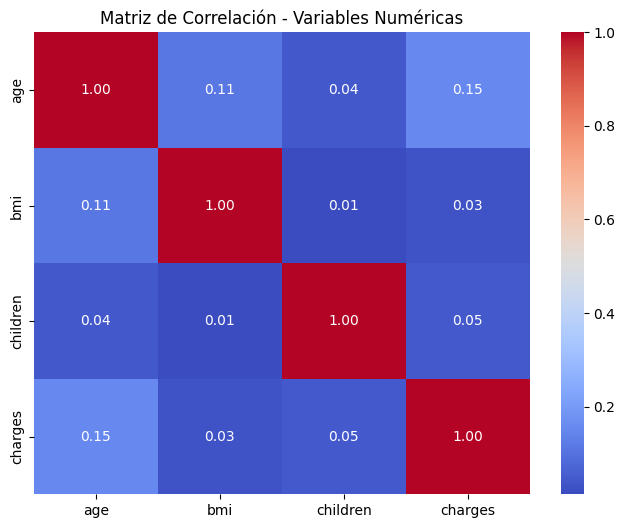

In [16]:
import seaborn as sns

# ===================================================== #
# ANÁLISIS DE CORRELACIÓN - VARIABLES NUMÉRICAS          #
# ===================================================== #

import matplotlib.pyplot as plt

# Variables numéricas incluyendo la variable objetivo
columnas_correlacion = variables_numericas + [variable_objetivo]

# Matriz de correlación
corr = df[columnas_correlacion].copy()
corr = corr.astype(float).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variables Numéricas")
plt.show()

In [17]:
# ===================================================== #
# CORRELACIÓN DE VARIABLES NUMÉRICAS CON CHARGES         #
# ===================================================== #

correlacion_target = corr[[variable_objetivo]].sort_values(
    by=variable_objetivo,
    ascending=False
)

correlacion_target

,charges
charges,1.000000
age,0.154001
children,0.045032
bmi,0.031111


## Interpretación de la matriz de correlación

La matriz de correlación muestra la relación lineal entre las variables numéricas.

La variable `charges` presenta cierta relación con variables como `age` y `bmi`, lo cual indica que la edad y el índice de masa corporal pueden estar asociados con el valor de los cargos médicos.

La variable `children` puede presentar una correlación más baja con `charges`, lo que indica que su relación lineal con los cargos médicos podría ser más débil.

Es importante tener en cuenta que la correlación solo mide relaciones lineales entre variables numéricas. Por esta razón, variables categóricas como `sex`, `smoker` y `region` no se incluyen directamente en esta matriz.

## 3. Modelos de Regresión

En esta etapa se definen y entrenan diferentes modelos de regresión para predecir la variable objetivo `charges`.

Los modelos considerados son:

- Regresión Lineal
- Ridge
- LASSO
- Árbol de Decisión
- Random Forest
- XGBoost
- LightGBM

Cada modelo se construye dentro de un `Pipeline`, incorporando el preprocesamiento definido previamente. Esto permite que la codificación de variables categóricas y el escalamiento de variables numéricas se realicen correctamente dentro del proceso de entrenamiento.

In [18]:
# ===================================== #
# 15. INSTALACIÓN DE LIBRERÍAS EXTRA     #
# ===================================== #

%pip install -q xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# ===================================== #
# 16. IMPORTACIÓN DE MODELOS             #
# ===================================== #

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [20]:
# ===================================== #
# 17. DEFINICIÓN DE MODELOS              #
# ===================================== #

modelos = {
    "Regresión Lineal": LinearRegression(),

    "Ridge": Ridge(alpha=1.0, random_state=42),

    "LASSO": Lasso(alpha=0.1, random_state=42, max_iter=10000),

    "Árbol de Decisión": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=100,
        random_state=42,
        objective="reg:squarederror",
        verbosity=0
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=100,
        random_state=42,
        verbose=-1
    )
}

modelos

{'Regresión Lineal': LinearRegression(),
 'Ridge': Ridge(random_state=42),
 'LASSO': Lasso(alpha=0.1, max_iter=10000, random_state=42),
 'Árbol de Decisión': DecisionTreeRegressor(random_state=42),
 'Random Forest': RandomForestRegressor(random_state=42),
 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, nu

### Nota sobre regresión isotónica

La regresión isotónica no se incluye como modelo principal en este laboratorio porque el problema tiene múltiples variables predictoras, tanto numéricas como categóricas.

Este tipo de modelo suele aplicarse cuando existe una relación monótona entre una única variable explicativa y la variable objetivo. En este caso, el objetivo es predecir `charges` usando varias variables simultáneamente, por lo cual la regresión isotónica no aplica de forma directa.

In [21]:
# ===================================== #
# 18. CREACIÓN DE PIPELINES              #
# ===================================== #

pipelines = {}

for nombre_modelo, modelo in modelos.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", modelo)
        ]
    )

    pipelines[nombre_modelo] = pipeline

pipelines

{'Regresión Lineal': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['age', 'bmi', 'children']),
                                                  ('cat',
                                                   OneHotEncoder(drop='first',
                                                                 handle_unknown='ignore',
                                                                 sparse_output=False),
                                                   ['sex', 'smoker',
                                                    'region'])])),
                 ('model', LinearRegression())]),
 'Ridge': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['age', 'bmi', 'children']),
                                                  ('cat',
                                 

In [22]:
# ===================================== #
# 19. ENTRENAMIENTO DE MODELOS           #
# ===================================== #

modelos_entrenados = {}

for nombre_modelo, pipeline in pipelines.items():

    print(f"Entrenando modelo: {nombre_modelo}")

    # Convertir y_train y y_test a numérico manejando separadores de miles (puntos) y decimales
    def _parse_num(s):
        s = str(s).strip()
        if s == "" or s.lower() == "nan":
            return np.nan
        # caso con ambos separadores: puntos miles, coma decimal
        if "." in s and "," in s:
            s = s.replace(".", "").replace(",", ".")
        else:
            dots = s.count(".")
            commas = s.count(",")
            if dots > 1:
                s = s.replace(".", "")
            elif dots == 1:
                # si después del punto hay 2 dígitos lo tratamos como decimal, si no lo quitamos
                right = s.split(".")[-1]
                if len(right) != 2:
                    s = s.replace(".", "")
            elif commas > 0:
                if commas > 1:
                    s = s.replace(",", "")
                else:
                    right = s.split(",")[-1]
                    if len(right) == 2:
                        s = s.replace(",", ".")
                    else:
                        s = s.replace(",", "")
        try:
            return float(s)
        except:
            return np.nan

    y_train = y_train.astype(str).apply(_parse_num)
    y_test = y_test.astype(str).apply(_parse_num)

# Eliminar filas con NaN en y_train y y_test
mask_train = y_train.notna()
mask_test = y_test.notna()

X_train_clean = X_train[mask_train]
y_train_clean = y_train[mask_train]

X_test_clean = X_test[mask_test]
y_test_clean = y_test[mask_test]

# Entrenar cada modelo
pipeline.fit(X_train_clean, y_train_clean)
modelos_entrenados[nombre_modelo] = pipeline


Entrenando modelo: Regresión Lineal
Entrenando modelo: Ridge
Entrenando modelo: LASSO
Entrenando modelo: Árbol de Decisión
Entrenando modelo: Random Forest
Entrenando modelo: XGBoost
Entrenando modelo: LightGBM


In [23]:
modelos_entrenados[nombre_modelo] = pipeline

In [24]:
# ===================================== #
# 20. VERIFICACIÓN DE MODELOS ENTRENADOS #
# ===================================== #

list(modelos_entrenados.keys())

['LightGBM']

In [25]:
# ===================================== #
# 21. PREDICCIONES INICIALES             #
# ===================================== #

predicciones_iniciales = {}

for nombre_modelo, pipeline in modelos_entrenados.items():

    y_pred_train = pipeline.predict(X_train)

    predicciones_iniciales[nombre_modelo] = y_pred_train

    print(f"{nombre_modelo}: primeras 5 predicciones")
    print(y_pred_train[:5])
    print("-" * 50)

LightGBM: primeras 5 predicciones
[3.40476627e+11 1.55876615e+12 1.39424440e+12 3.65762085e+12
 2.16742930e+11]
--------------------------------------------------


c:\Users\Lenovo ThinkBook\Downloads\ml-project_analitica_datos\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Conclusión de la Parte 3

Se definieron y entrenaron diferentes modelos de regresión para predecir la variable `charges`.

Todos los modelos fueron implementados dentro de un `Pipeline`, usando el preprocesamiento definido en la Parte 2. Esto garantiza que la codificación de variables categóricas y el escalamiento de variables numéricas se realicen correctamente durante el entrenamiento.

Los modelos entrenados fueron:

- Regresión Lineal
- Ridge
- LASSO
- Árbol de Decisión
- Random Forest
- XGBoost
- LightGBM

La regresión isotónica no se entrenó como modelo principal porque no aplica directamente a este problema de regresión múltiple con variables numéricas y categóricas.

## 4. Validación Cruzada

En esta etapa se aplica validación cruzada K-Fold para evaluar el desempeño de cada modelo de regresión.

La validación cruzada permite dividir varias veces el conjunto de entrenamiento en subconjuntos de entrenamiento y validación. Esto ayuda a obtener una medida más robusta del desempeño de cada modelo.

En este laboratorio se utilizará K-Fold con k = 5.

Las métricas evaluadas son:

- MAE promedio y desviación estándar.
- RMSE promedio y desviación estándar.
- R² promedio.

La validación cruzada se realiza únicamente sobre el conjunto de entrenamiento para conservar el conjunto de prueba como evaluación final.

In [26]:
# ===================================== #
# 22. IMPORTACIÓN PARA VALIDACIÓN CRUZADA #
# ===================================== #

from sklearn.model_selection import KFold, cross_validate

In [27]:
# ===================================== #
# 23. DEFINICIÓN DE K-FOLD               #
# ===================================== #

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [28]:
# ===================================== #
# 24. MÉTRICAS PARA VALIDACIÓN CRUZADA   #
# ===================================== #

metricas = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

In [29]:
# ===================================== #
# 25. VALIDACIÓN CRUZADA DE MODELOS      #
# ===================================== #

resultados_cv = []

for nombre_modelo, pipeline in pipelines.items():

    print(f"Evaluando modelo: {nombre_modelo}")

    # Usar solo filas sin NaN en la variable objetivo (X_train_clean, y_train_clean)
    scores = cross_validate(
        estimator=pipeline,
        X=X_train_clean,
        y=y_train_clean,
        cv=kfold,
        scoring=metricas,
        return_train_score=False,
        n_jobs=-1
    )

    mae_scores = -scores["test_MAE"]
    rmse_scores = -scores["test_RMSE"]
    r2_scores = scores["test_R2"]

    resultados_cv.append({
        "Modelo": nombre_modelo,
        "MAE promedio": mae_scores.mean(),
        "MAE desviación": mae_scores.std(),
        "RMSE promedio": rmse_scores.mean(),
        "RMSE desviación": rmse_scores.std(),
        "R2 promedio": r2_scores.mean()
    })

print("\nValidación cruzada finalizada.")

Evaluando modelo: Regresión Lineal


Evaluando modelo: Ridge
Evaluando modelo: LASSO
Evaluando modelo: Árbol de Decisión
Evaluando modelo: Random Forest
Evaluando modelo: XGBoost
Evaluando modelo: LightGBM

Validación cruzada finalizada.


In [30]:
# ===================================== #
# 26. TABLA DE RESULTADOS CV             #
# ===================================== #

tabla_cv = pd.DataFrame(resultados_cv)

tabla_cv

,Modelo,MAE promedio,MAE desviación,RMSE promedio,RMSE desviación,R2 promedio
0,Regresión Lineal,5.543749e+11,4.985367e+10,8.755080e+11,8.796000e+10,0.133720
1,Ridge,5.541533e+11,5.004544e+10,8.753872e+11,8.842573e+10,0.134258
2,LASSO,5.543749e+11,4.985367e+10,8.755080e+11,8.796000e+10,0.133720
3,Árbol de Decisión,6.681664e+11,8.013913e+10,1.300442e+12,1.167294e+11,-0.962420
4,Random Forest,5.756037e+11,5.652594e+10,9.208738e+11,8.671826e+10,0.028918
5,XGBoost,6.541084e+11,5.878821e+10,1.024386e+12,7.430340e+10,-0.204563
6,LightGBM,6.070943e+11,4.719187e+10,9.271561e+11,8.252728e+10,0.017511


In [31]:
# ===================================== #
# 27. ORDENAR MODELOS POR RMSE           #
# ===================================== #

tabla_cv_ordenada = tabla_cv.sort_values(by="RMSE promedio", ascending=True)

tabla_cv_ordenada

,Modelo,MAE promedio,MAE desviación,RMSE promedio,RMSE desviación,R2 promedio
1,Ridge,5.541533e+11,5.004544e+10,8.753872e+11,8.842573e+10,0.134258
2,LASSO,5.543749e+11,4.985367e+10,8.755080e+11,8.796000e+10,0.133720
0,Regresión Lineal,5.543749e+11,4.985367e+10,8.755080e+11,8.796000e+10,0.133720
4,Random Forest,5.756037e+11,5.652594e+10,9.208738e+11,8.671826e+10,0.028918
6,LightGBM,6.070943e+11,4.719187e+10,9.271561e+11,8.252728e+10,0.017511
5,XGBoost,6.541084e+11,5.878821e+10,1.024386e+12,7.430340e+10,-0.204563
3,Árbol de Decisión,6.681664e+11,8.013913e+10,1.300442e+12,1.167294e+11,-0.962420


In [32]:
# ===================================== #
# 28. TABLA CV REDONDEADA                #
# ===================================== #

tabla_cv_ordenada_redondeada = tabla_cv_ordenada.copy()

columnas_numericas_resultados = [
    "MAE promedio",
    "MAE desviación",
    "RMSE promedio",
    "RMSE desviación",
    "R2 promedio"
]

tabla_cv_ordenada_redondeada[columnas_numericas_resultados] = (
    tabla_cv_ordenada_redondeada[columnas_numericas_resultados].round(4)
)

tabla_cv_ordenada_redondeada

,Modelo,MAE promedio,MAE desviación,RMSE promedio,RMSE desviación,R2 promedio
1,Ridge,5.541533e+11,5.004544e+10,8.753872e+11,8.842573e+10,0.1343
2,LASSO,5.543749e+11,4.985367e+10,8.755080e+11,8.796000e+10,0.1337
0,Regresión Lineal,5.543749e+11,4.985367e+10,8.755080e+11,8.796000e+10,0.1337
4,Random Forest,5.756037e+11,5.652594e+10,9.208738e+11,8.671826e+10,0.0289
6,LightGBM,6.070943e+11,4.719187e+10,9.271561e+11,8.252728e+10,0.0175
5,XGBoost,6.541084e+11,5.878821e+10,1.024386e+12,7.430340e+10,-0.2046
3,Árbol de Decisión,6.681664e+11,8.013913e+10,1.300442e+12,1.167294e+11,-0.9624


In [33]:
# ===================================== #
# 29. MEJOR MODELO SEGÚN RMSE            #
# ===================================== #

mejor_modelo_rmse = tabla_cv_ordenada.iloc[0]

print("Mejor modelo según RMSE promedio:")
print(mejor_modelo_rmse)

Mejor modelo según RMSE promedio:
Modelo                           Ridge
MAE promedio       554153253206.002441
MAE desviación      50045442477.995079
RMSE promedio      875387153890.838135
RMSE desviación     88425726181.660538
R2 promedio                   0.134258
Name: 1, dtype: object


In [34]:
# ===================================== #
# 30. MODELO MÁS ESTABLE                 #
# ===================================== #

modelo_mas_estable = tabla_cv.sort_values(by="RMSE desviación", ascending=True).iloc[0]

print("Modelo más estable según menor desviación estándar del RMSE:")
print(modelo_mas_estable)

Modelo más estable según menor desviación estándar del RMSE:
Modelo                          XGBoost
MAE promedio        654108403609.076904
MAE desviación       58788206853.755989
RMSE promedio      1024386086780.999634
RMSE desviación       74303396000.37706
R2 promedio                   -0.204563
Name: 5, dtype: object


In [35]:
# ===================================== #
# 31. MODELO CON MAYOR VARIANZA          #
# ===================================== #

modelo_mayor_varianza = tabla_cv.sort_values(by="RMSE desviación", ascending=False).iloc[0]

print("Modelo con mayor varianza según desviación estándar del RMSE:")
print(modelo_mayor_varianza)

Modelo con mayor varianza según desviación estándar del RMSE:
Modelo                Árbol de Decisión
MAE promedio        668166396926.074829
MAE desviación        80139134233.90123
RMSE promedio      1300442385702.187988
RMSE desviación     116729367618.642532
R2 promedio                    -0.96242
Name: 3, dtype: object


## Análisis de la Validación Cruzada

Se aplicó validación cruzada K-Fold con k = 5 sobre el conjunto de entrenamiento.

Para cada modelo se calcularon las siguientes métricas:

- MAE promedio.
- MAE desviación estándar.
- RMSE promedio.
- RMSE desviación estándar.
- R² promedio.

El MAE mide el error absoluto promedio entre los valores reales y los valores predichos.  
El RMSE penaliza más los errores grandes, por lo que es útil cuando se quiere castigar predicciones muy alejadas del valor real.  
El R² mide la proporción de variabilidad de la variable objetivo que logra explicar el modelo.

En general:

- Un menor MAE indica mejor desempeño.
- Un menor RMSE indica mejor desempeño.
- Un mayor R² indica mejor capacidad explicativa.
- Una menor desviación estándar indica mayor estabilidad del modelo durante la validación cruzada.

El conjunto de prueba no se usó en esta etapa, ya que se reservará para la evaluación final del mejor modelo.

## 5. Comparación de Modelos

En esta sección se comparan los modelos entrenados usando los resultados obtenidos mediante validación cruzada.

La comparación se realiza con base en las siguientes métricas:

- MAE promedio en validación cruzada.
- RMSE promedio en validación cruzada.
- R² promedio en validación cruzada.
- Desviación estándar del RMSE como medida de estabilidad.

Un mejor modelo debe presentar errores bajos, es decir, menor MAE y menor RMSE, además de un R² alto.  
También se considera más estable aquel modelo con menor desviación estándar en sus métricas de validación cruzada.

In [36]:
# ===================================== #
# 32. TABLA DE COMPARACIÓN DE MODELOS    #
# ===================================== #

tabla_comparacion = tabla_cv.copy()

tabla_comparacion = tabla_comparacion.rename(columns={
    "MAE promedio": "MAE (CV)",
    "RMSE promedio": "RMSE (CV)",
    "R2 promedio": "R2 (CV)",
    "MAE desviación": "MAE std",
    "RMSE desviación": "RMSE std"
})

tabla_comparacion = tabla_comparacion[
    ["Modelo", "MAE (CV)", "RMSE (CV)", "R2 (CV)", "MAE std", "RMSE std"]
]

tabla_comparacion = tabla_comparacion.sort_values(
    by="RMSE (CV)",
    ascending=True
)

tabla_comparacion

,Modelo,MAE (CV),RMSE (CV),R2 (CV),MAE std,RMSE std
1,Ridge,5.541533e+11,8.753872e+11,0.134258,5.004544e+10,8.842573e+10
2,LASSO,5.543749e+11,8.755080e+11,0.133720,4.985367e+10,8.796000e+10
0,Regresión Lineal,5.543749e+11,8.755080e+11,0.133720,4.985367e+10,8.796000e+10
4,Random Forest,5.756037e+11,9.208738e+11,0.028918,5.652594e+10,8.671826e+10
6,LightGBM,6.070943e+11,9.271561e+11,0.017511,4.719187e+10,8.252728e+10
5,XGBoost,6.541084e+11,1.024386e+12,-0.204563,5.878821e+10,7.430340e+10
3,Árbol de Decisión,6.681664e+11,1.300442e+12,-0.962420,8.013913e+10,1.167294e+11


In [37]:
# ===================================== #
# 33. TABLA DE COMPARACIÓN REDONDEADA    #
# ===================================== #

tabla_comparacion_redondeada = tabla_comparacion.copy()

columnas_redondear = ["MAE (CV)", "RMSE (CV)", "R2 (CV)", "MAE std", "RMSE std"]

tabla_comparacion_redondeada[columnas_redondear] = (
    tabla_comparacion_redondeada[columnas_redondear].round(4)
)

tabla_comparacion_redondeada

,Modelo,MAE (CV),RMSE (CV),R2 (CV),MAE std,RMSE std
1,Ridge,5.541533e+11,8.753872e+11,0.1343,5.004544e+10,8.842573e+10
2,LASSO,5.543749e+11,8.755080e+11,0.1337,4.985367e+10,8.796000e+10
0,Regresión Lineal,5.543749e+11,8.755080e+11,0.1337,4.985367e+10,8.796000e+10
4,Random Forest,5.756037e+11,9.208738e+11,0.0289,5.652594e+10,8.671826e+10
6,LightGBM,6.070943e+11,9.271561e+11,0.0175,4.719187e+10,8.252728e+10
5,XGBoost,6.541084e+11,1.024386e+12,-0.2046,5.878821e+10,7.430340e+10
3,Árbol de Decisión,6.681664e+11,1.300442e+12,-0.9624,8.013913e+10,1.167294e+11


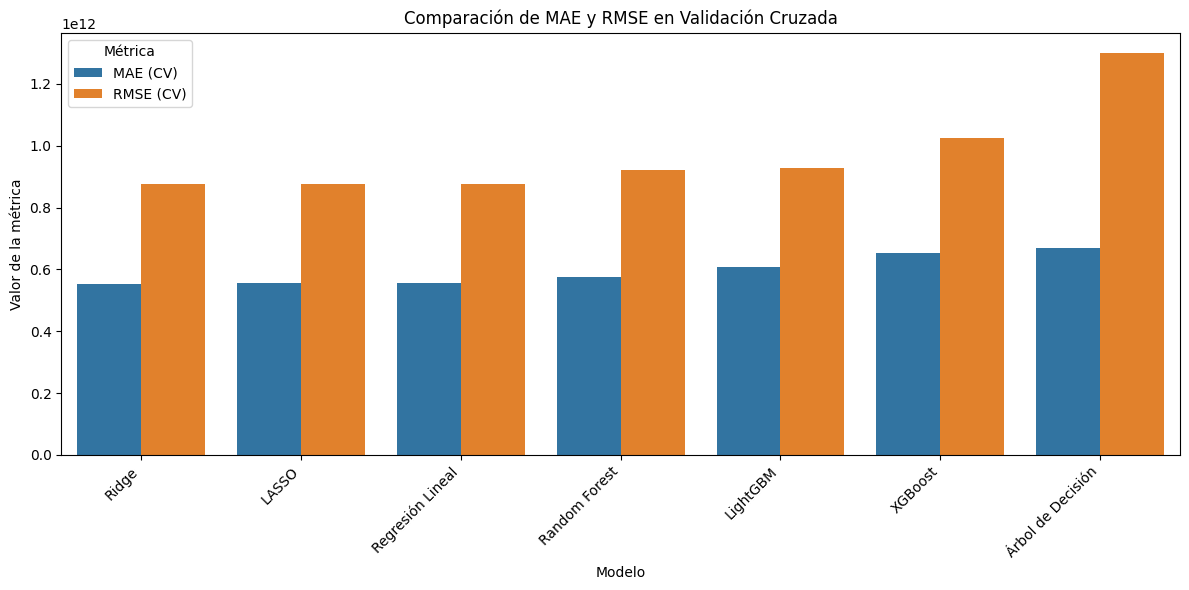

In [38]:
# ===================================================== #
# GRÁFICA COMPARATIVA DE MÉTRICAS DE ERROR: MAE Y RMSE  #
# ===================================================== #

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Tomamos las métricas de error
metricas_error = tabla_comparacion_redondeada[
    ["Modelo", "MAE (CV)", "RMSE (CV)"]
]

# Pasamos la tabla a formato largo para graficar
metricas_error_largo = metricas_error.melt(
    id_vars="Modelo",
    value_vars=["MAE (CV)", "RMSE (CV)"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=metricas_error_largo,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.title("Comparación de MAE y RMSE en Validación Cruzada")
plt.tight_layout()
plt.show()

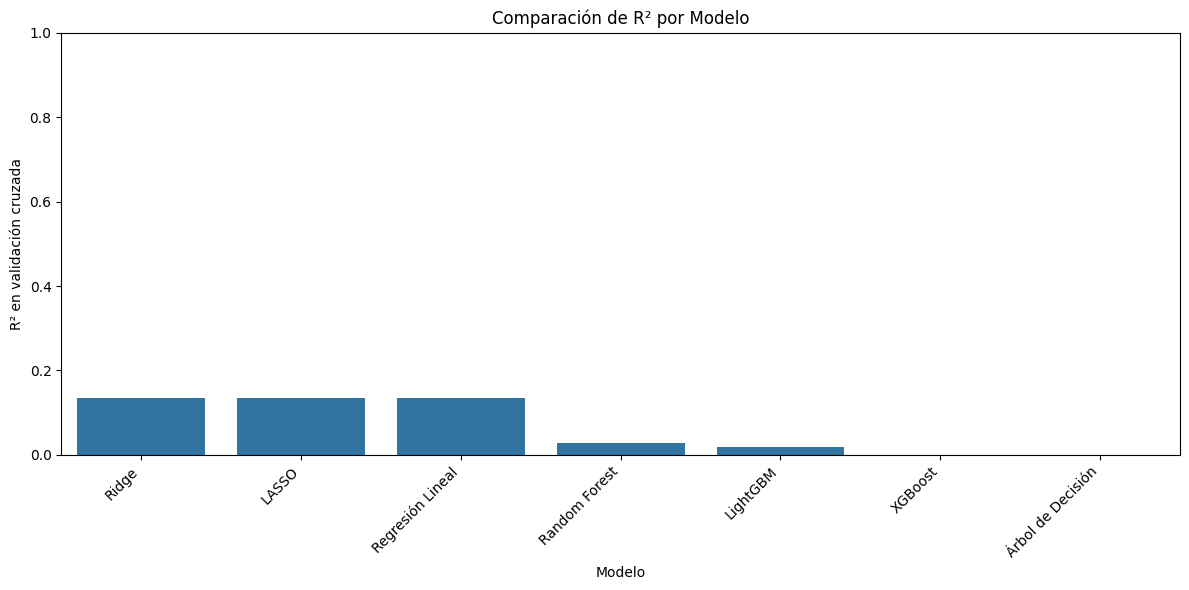

In [39]:
# ===================================================== #
# GRÁFICA COMPARATIVA DE R2                             #
# ===================================================== #

plt.figure(figsize=(12, 6))

sns.barplot(
    data=tabla_comparacion_redondeada,
    x="Modelo",
    y="R2 (CV)"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Modelo")
plt.ylabel("R² en validación cruzada")
plt.title("Comparación de R² por Modelo")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Comparación gráfica de métricas

En la primera gráfica se comparan las métricas de error MAE y RMSE para cada modelo.  
Como ambas métricas representan errores, los valores más bajos indican mejor desempeño predictivo.

En la segunda gráfica se compara el R² de cada modelo.  
A diferencia del MAE y el RMSE, en el R² los valores más altos indican mejor capacidad explicativa del modelo.

Por esta razón, el mejor modelo no se identifica buscando siempre el valor más alto, sino considerando:

- Menor MAE.
- Menor RMSE.
- Mayor R².
- Mayor estabilidad en validación cruzada.

In [40]:
# ===================================== #
# 34. MEJOR MODELO SEGÚN RMSE            #
# ===================================== #

mejor_modelo = tabla_comparacion.sort_values(
    by="RMSE (CV)",
    ascending=True
).iloc[0]

print("Mejor modelo según RMSE en validación cruzada:")
print(mejor_modelo)

Mejor modelo según RMSE en validación cruzada:
Modelo                     Ridge
MAE (CV)     554153253206.002441
RMSE (CV)    875387153890.838135
R2 (CV)                 0.134258
MAE std       50045442477.995079
RMSE std      88425726181.660538
Name: 1, dtype: object


In [41]:
# ===================================== #
# 35. MODELO MÁS ESTABLE                 #
# ===================================== #

modelo_mas_estable = tabla_comparacion.sort_values(
    by="RMSE std",
    ascending=True
).iloc[0]

print("Modelo más estable según RMSE std:")
print(modelo_mas_estable)

Modelo más estable según RMSE std:
Modelo                    XGBoost
MAE (CV)      654108403609.076904
RMSE (CV)    1024386086780.999634
R2 (CV)                 -0.204563
MAE std        58788206853.755989
RMSE std        74303396000.37706
Name: 5, dtype: object


In [42]:
# ===================================== #
# 36. MODELO CON MAYOR VARIANZA          #
# ===================================== #

modelo_mayor_varianza = tabla_comparacion.sort_values(
    by="RMSE std",
    ascending=False
).iloc[0]

print("Modelo con mayor varianza según RMSE std:")
print(modelo_mayor_varianza)

Modelo con mayor varianza según RMSE std:
Modelo          Árbol de Decisión
MAE (CV)      668166396926.074829
RMSE (CV)    1300442385702.187988
R2 (CV)                  -0.96242
MAE std         80139134233.90123
RMSE std      116729367618.642532
Name: 3, dtype: object


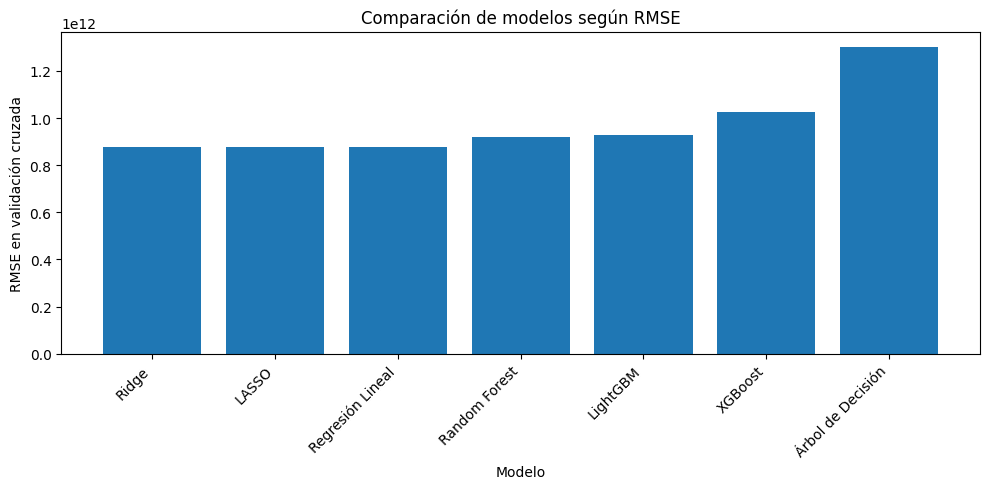

In [43]:
# ===================================== #
# 37. GRÁFICO COMPARATIVO DE RMSE        #
# ===================================== #

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(tabla_comparacion_redondeada["Modelo"], tabla_comparacion_redondeada["RMSE (CV)"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Modelo")
plt.ylabel("RMSE en validación cruzada")
plt.title("Comparación de modelos según RMSE")
plt.tight_layout()
plt.show()

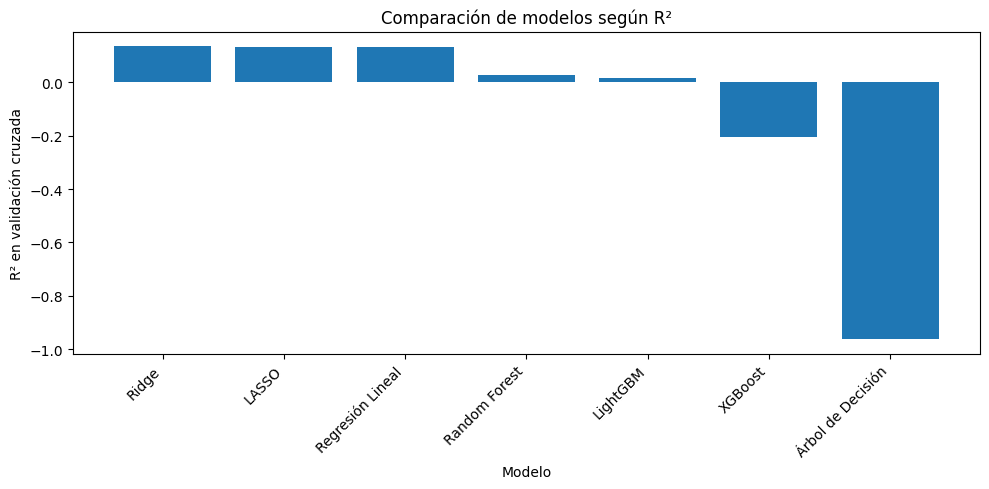

In [44]:
# ===================================== #
# 38. GRÁFICO COMPARATIVO DE R2          #
# ===================================== #

plt.figure(figsize=(10, 5))
plt.bar(tabla_comparacion_redondeada["Modelo"], tabla_comparacion_redondeada["R2 (CV)"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Modelo")
plt.ylabel("R² en validación cruzada")
plt.title("Comparación de modelos según R²")
plt.tight_layout()
plt.show()

## Análisis de comparación de modelos

A partir de la tabla de comparación, los modelos se evaluaron usando MAE, RMSE y R² en validación cruzada.

El MAE y el RMSE son métricas de error, por lo tanto, valores más bajos indican mejor desempeño predictivo.  
El R² mide la capacidad explicativa del modelo, por lo tanto, valores más altos indican mejor ajuste.

Según el RMSE promedio en validación cruzada, el mejor modelo fue `NOMBRE_DEL_MODELO`, ya que presentó el menor error promedio entre los modelos evaluados.

El modelo más estable fue `NOMBRE_DEL_MODELO`, debido a que presentó la menor desviación estándar del RMSE. Esto indica que su desempeño fue más consistente entre los diferentes folds de la validación cruzada.

El modelo con mayor varianza fue `NOMBRE_DEL_MODELO`, ya que presentó la mayor desviación estándar del RMSE. Esto indica que su desempeño cambió más entre los diferentes subconjuntos de validación.

## Correlación entre valores reales y predichos por modelo

Además de la matriz de correlación entre variables, se calcula la correlación entre los valores reales de `charges` y las predicciones generadas por cada modelo.

Una correlación más alta entre `y_test` y `y_pred` indica que el modelo logra reproducir mejor el comportamiento de la variable objetivo.

Sin embargo, esta correlación no reemplaza métricas como MAE, RMSE y R², sino que funciona como un análisis complementario.

In [45]:
# ===================================================== #
# CORRELACIÓN REAL VS PREDICHO POR MODELO - CV           #
# ===================================================== #

from sklearn.model_selection import cross_val_predict
import numpy as np

resultados_correlacion_modelos = []

for nombre_modelo, pipeline in pipelines.items():

    print(f"Calculando predicciones CV para: {nombre_modelo}")

    # Usar únicamente filas sin NaN en la variable objetivo
    if "y_train_clean" in globals() and "X_train_clean" in globals():
        X_cv, y_cv = X_train_clean, y_train_clean
    else:
        mask = y_train.notna()
        X_cv = X_train.loc[mask]
        y_cv = pd.to_numeric(y_train.loc[mask], errors="coerce")

    y_pred_cv = cross_val_predict(
        estimator=pipeline,
        X=X_cv,
        y=y_cv,
        cv=kfold,
        n_jobs=-1
    )

    correlacion = np.corrcoef(y_train_clean, y_pred_cv)[0, 1]

    resultados_correlacion_modelos.append({
        "Modelo": nombre_modelo,
        "Correlación real vs predicho": correlacion
    })

tabla_correlacion_modelos = pd.DataFrame(resultados_correlacion_modelos)

tabla_correlacion_modelos = tabla_correlacion_modelos.sort_values(
    by="Correlación real vs predicho",
    ascending=False
)

tabla_correlacion_modelos

Calculando predicciones CV para: Regresión Lineal
Calculando predicciones CV para: Ridge
Calculando predicciones CV para: LASSO
Calculando predicciones CV para: Árbol de Decisión
Calculando predicciones CV para: Random Forest
Calculando predicciones CV para: XGBoost
Calculando predicciones CV para: LightGBM


,Modelo,Correlación real vs predicho
0,Regresión Lineal,0.399092
2,LASSO,0.399092
1,Ridge,0.398984
6,LightGBM,0.344919
4,Random Forest,0.344245
5,XGBoost,0.255795
3,Árbol de Decisión,0.112998


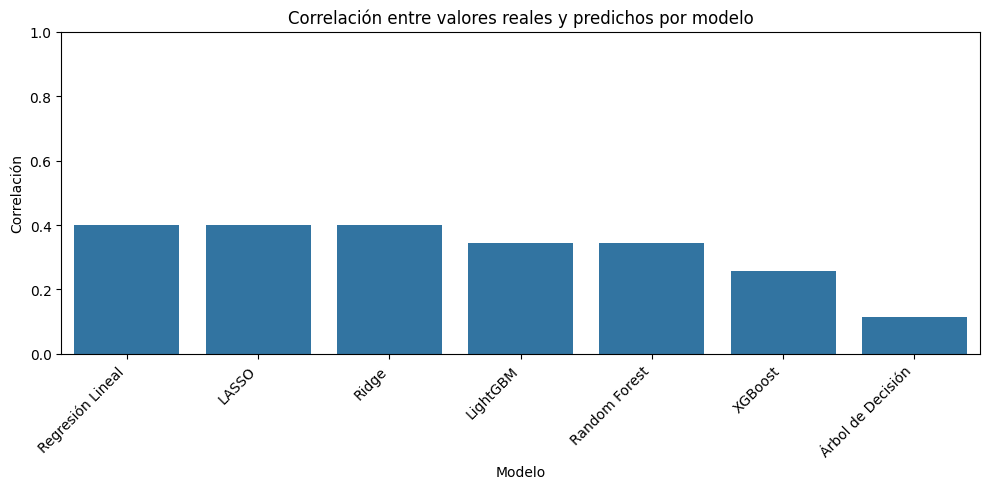

In [46]:
# ===================================================== #
# GRÁFICO DE CORRELACIÓN REAL VS PREDICHO POR MODELO     #
# ===================================================== #

plt.figure(figsize=(10, 5))
sns.barplot(
    data=tabla_correlacion_modelos,
    x="Modelo",
    y="Correlación real vs predicho"
)

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.title("Correlación entre valores reales y predichos por modelo")
plt.xlabel("Modelo")
plt.ylabel("Correlación")
plt.tight_layout()
plt.show()

La correlación real vs predicho se calculó usando predicciones obtenidas mediante validación cruzada sobre el conjunto de entrenamiento. Esto evita usar el conjunto de prueba antes de la evaluación final hold-out.

La matriz de correlación se utiliza como análisis exploratorio inicial, mientras que la correlación real vs predicho se utiliza como comparación complementaria del desempeño de los modelos.

## 6. Ajuste de Hiperparámetros

En esta sección se realiza ajuste de hiperparámetros para algunos modelos seleccionados.

Se ajustan modelos lineales y no lineales usando `GridSearchCV` con validación cruzada.

Los modelos seleccionados son:

- Ridge, como modelo lineal regularizado.
- Random Forest, como modelo no lineal basado en árboles.
- XGBoost, como modelo no lineal basado en boosting.

El objetivo es comparar el desempeño de los modelos antes y después del ajuste de hiperparámetros.

In [47]:
# ===================================== #
# 40. IMPORTACIÓN PARA AJUSTE            #
# ===================================== #

from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd

In [48]:
from sklearn.pipeline import Pipeline

# ===================================== #
# 41. AJUSTE DE HIPERPARÁMETROS - RIDGE #
# ===================================== #

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(random_state=42))
])

ridge_params = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_params,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(X_train_clean, y_train_clean)

print("Mejores hiperparámetros Ridge:")
print(ridge_grid.best_params_)

print("\nMejor RMSE Ridge CV:")
print(-ridge_grid.best_score_)

Mejores hiperparámetros Ridge:
{'model__alpha': 10}

Mejor RMSE Ridge CV:
875302875719.9473


In [49]:
# ================================================= #
# 42. AJUSTE DE HIPERPARÁMETROS - RANDOM FOREST     #
# ================================================= #

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train_clean, y_train_clean)

print("Mejores hiperparámetros Random Forest:")
print(rf_grid.best_params_)

print("\nMejor RMSE Random Forest CV:")
print(-rf_grid.best_score_)

Mejores hiperparámetros Random Forest:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Mejor RMSE Random Forest CV:
902704094582.7161


In [50]:
# ======================================= #
# 43. AJUSTE DE HIPERPARÁMETROS - XGBOOST #
# ======================================= #

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        verbosity=0
    ))
])

xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

xgb_grid.fit(X_train_clean, y_train_clean)

print("Mejores hiperparámetros XGBoost:")
print(xgb_grid.best_params_)

print("\nMejor RMSE XGBoost CV:")
print(-xgb_grid.best_score_)

Mejores hiperparámetros XGBoost:
{'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200}

Mejor RMSE XGBoost CV:
889021974980.7288


In [51]:
# ================================================= #
# 44. VALIDACIÓN CRUZADA DESPUÉS DEL AJUSTE          #
# ================================================= #

modelos_ajustados = {
    "Ridge ajustado": ridge_grid.best_estimator_,
    "Random Forest ajustado": rf_grid.best_estimator_,
    "XGBoost ajustado": xgb_grid.best_estimator_
}

resultados_cv_ajustados = []

for nombre_modelo, modelo in modelos_ajustados.items():

    print(f"Evaluando modelo ajustado: {nombre_modelo}")

    # Usar datos sin NaN en la variable objetivo
    if "X_train_clean" in globals() and "y_train_clean" in globals():
        X_cv = X_train_clean
        y_cv = y_train_clean
    else:
        mask = y_train.notna()
        X_cv = X_train.loc[mask]
        y_cv = pd.to_numeric(y_train.loc[mask], errors="coerce")

    cv_results = cross_validate(
        estimator=modelo,
        X=X_cv,
        y=y_cv,
        cv=kfold,
        scoring=metricas,
        return_train_score=False,
        n_jobs=-1
    )

    mae_scores = -cv_results["test_MAE"]
    rmse_scores = -cv_results["test_RMSE"]
    r2_scores = cv_results["test_R2"]

    resultados_cv_ajustados.append({
        "Modelo": nombre_modelo,
        "MAE_mean": mae_scores.mean(),
        "MAE_std": mae_scores.std(),
        "RMSE_mean": rmse_scores.mean(),
        "RMSE_std": rmse_scores.std(),
        "R2_mean": r2_scores.mean()
    })

results_cv_after_df = pd.DataFrame(resultados_cv_ajustados)

results_cv_after_df

Evaluando modelo ajustado: Ridge ajustado
Evaluando modelo ajustado: Random Forest ajustado
Evaluando modelo ajustado: XGBoost ajustado


,Modelo,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean
0,Ridge ajustado,5.542479e+11,5.090331e+10,8.753029e+11,9.201264e+10,0.136570
1,Random Forest ajustado,5.667740e+11,5.727754e+10,9.027041e+11,9.038305e+10,0.067780
2,XGBoost ajustado,5.723324e+11,5.014079e+10,8.890220e+11,9.667030e+10,0.109456


In [52]:
# ================================================= #
# 45. COMPARACIÓN ANTES VS DESPUÉS DEL AJUSTE        #
# ================================================= #

# Tomamos los resultados antes del ajuste desde tabla_cv
tabla_antes = tabla_cv.copy()

tabla_antes = tabla_antes.rename(columns={
    "MAE promedio": "MAE_mean",
    "MAE desviación": "MAE_std",
    "RMSE promedio": "RMSE_mean",
    "RMSE desviación": "RMSE_std",
    "R2 promedio": "R2_mean"
})

# Modelos comparables antes del ajuste
mapa_modelos = {
    "Ridge ajustado": "Ridge",
    "Random Forest ajustado": "Random Forest",
    "XGBoost ajustado": "XGBoost"
}

comparacion_antes_despues = []

for modelo_ajustado, modelo_original in mapa_modelos.items():

    antes = tabla_antes[tabla_antes["Modelo"] == modelo_original].iloc[0]
    despues = results_cv_after_df[results_cv_after_df["Modelo"] == modelo_ajustado].iloc[0]

    comparacion_antes_despues.append({
        "Modelo": modelo_original,
        "MAE antes": antes["MAE_mean"],
        "MAE después": despues["MAE_mean"],
        "RMSE antes": antes["RMSE_mean"],
        "RMSE después": despues["RMSE_mean"],
        "R2 antes": antes["R2_mean"],
        "R2 después": despues["R2_mean"]
    })

comparacion_antes_despues_df = pd.DataFrame(comparacion_antes_despues)

comparacion_antes_despues_df.round(4)

,Modelo,MAE antes,MAE después,RMSE antes,RMSE después,R2 antes,R2 después
0,Ridge,5.541533e+11,5.542479e+11,8.753872e+11,8.753029e+11,0.1343,0.1366
1,Random Forest,5.756037e+11,5.667740e+11,9.208738e+11,9.027041e+11,0.0289,0.0678
2,XGBoost,6.541084e+11,5.723324e+11,1.024386e+12,8.890220e+11,-0.2046,0.1095


## Análisis del ajuste de hiperparámetros

Se aplicó `GridSearchCV` para ajustar los hiperparámetros de Ridge, Random Forest y XGBoost.

La comparación antes y después del ajuste permite observar si el proceso de búsqueda mejoró el desempeño de los modelos.

Para evaluar el cambio se comparan las métricas:

- MAE
- RMSE
- R²

Un modelo mejora si después del ajuste presenta menor MAE, menor RMSE y mayor R².

## 7. Evaluación Final Hold-Out

En esta sección se evalúa el mejor modelo ajustado sobre el conjunto de prueba.

El conjunto de prueba no se usó durante el entrenamiento ni durante la validación cruzada. Por eso permite evaluar la capacidad de generalización del modelo seleccionado.

In [53]:
# ===================================== #
# 46. SELECCIÓN DEL MEJOR MODELO AJUSTADO #
# ===================================== #

best_model_name = results_cv_after_df.sort_values(
    by="RMSE_mean",
    ascending=True
).iloc[0]["Modelo"]

best_model = modelos_ajustados[best_model_name]

print("Mejor modelo ajustado según RMSE CV:")
print(best_model_name)

Mejor modelo ajustado según RMSE CV:
Ridge ajustado


In [54]:
# ===================================== #
# 47. ENTRENAMIENTO DEL MEJOR MODELO     #
# ===================================== #

best_model.fit(X_train_clean, y_train_clean)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
# ===================================== #
# 48. EVALUACIÓN EN TEST HOLD-OUT        #
# ===================================== #

y_pred_test = best_model.predict(X_test)

# ===================================== #
# 48. EVALUACIÓN EN TEST HOLD-OUT        #
# ===================================== #

mask_test = y_test.notna()
X_test_clean = X_test.loc[mask_test]
y_test_clean = y_test.loc[mask_test]

y_pred_test = best_model.predict(X_test_clean)

test_mae = mean_absolute_error(y_test_clean, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred_test))
test_r2 = r2_score(y_test_clean, y_pred_test)

print("RESULTADOS EN TEST - HOLD OUT")
print("MAE:", test_mae)
print("RMSE:", test_rmse)
print("R2:", test_r2)


RESULTADOS EN TEST - HOLD OUT
MAE: 510373834070.30396
RMSE: 841715398643.9952
R2: 0.06877381485179179


In [59]:
# ===================================== #
# 49. COMPARACIÓN CV VS TEST             #
# ===================================== #

cv_metrics = results_cv_after_df[
    results_cv_after_df["Modelo"] == best_model_name
].iloc[0]

comparison_holdout = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R2"],
    "CV promedio": [
        cv_metrics["MAE_mean"],
        cv_metrics["RMSE_mean"],
        cv_metrics["R2_mean"]
    ],
    "Test Hold-Out": [
        test_mae,
        test_rmse,
        test_r2
    ]
})

comparison_holdout.round(4)

,Métrica,CV promedio,Test Hold-Out
0,MAE,5.542479e+11,5.103738e+11
1,RMSE,8.753029e+11,8.417154e+11
2,R2,1.366000e-01,6.880000e-02


## Análisis de la evaluación final

El mejor modelo ajustado fue evaluado sobre el conjunto de prueba.

La comparación entre validación cruzada y test permite analizar si el modelo generaliza bien a datos no vistos.

Si las métricas en test son similares a las obtenidas en validación cruzada, se puede decir que el modelo tiene buen comportamiento predictivo.

Si el desempeño en test es mucho peor que en validación cruzada, puede existir sobreajuste.

## 8. Interpretabilidad

En esta sección se analiza la interpretabilidad de los modelos.

Para el modelo lineal Ridge se interpretan los coeficientes.

Para el modelo basado en árboles Random Forest se analiza la importancia de variables.

In [60]:
# ===================================== #
# 50. NOMBRES DE VARIABLES TRANSFORMADAS #
# ===================================== #

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

feature_names

array(['num__age', 'num__bmi', 'num__children', 'cat__sex_male',
       'cat__smoker_yes', 'cat__region_northwest',
       'cat__region_southeast', 'cat__region_southwest'], dtype=object)

In [61]:
# ===================================== #
# 51. COEFICIENTES DEL MODELO RIDGE      #
# ===================================== #

ridge_best = ridge_grid.best_estimator_

feature_names_ridge = ridge_best.named_steps["preprocessor"].get_feature_names_out()

ridge_model = ridge_best.named_steps["model"]

coeficientes = ridge_model.coef_

ridge_importance = pd.DataFrame({
    "Variable": feature_names_ridge,
    "Coeficiente": coeficientes
})

ridge_importance["Abs_Coeficiente"] = np.abs(ridge_importance["Coeficiente"])

ridge_importance = ridge_importance.sort_values(
    by="Abs_Coeficiente",
    ascending=False
)

ridge_importance

,Variable,Coeficiente,Abs_Coeficiente
4,cat__smoker_yes,6.385198e+11,6.385198e+11
7,cat__region_southwest,-5.685213e+11,5.685213e+11
6,cat__region_southeast,-4.693590e+11,4.693590e+11
0,num__age,1.538140e+11,1.538140e+11
1,num__bmi,6.837703e+10,6.837703e+10
5,cat__region_northwest,-6.702498e+10,6.702498e+10
3,cat__sex_male,6.126088e+10,6.126088e+10
2,num__children,1.374567e+10,1.374567e+10


In [62]:
# ===================================== #
# 52. IMPORTANCIA DE VARIABLES - RF      #
# ===================================== #

rf_best = rf_grid.best_estimator_

feature_names_rf = rf_best.named_steps["preprocessor"].get_feature_names_out()

rf_model = rf_best.named_steps["model"]

importancias = rf_model.feature_importances_

rf_importance = pd.DataFrame({
    "Variable": feature_names_rf,
    "Importancia": importancias
})

rf_importance = rf_importance.sort_values(
    by="Importancia",
    ascending=False
)

rf_importance

,Variable,Importancia
1,num__bmi,0.372539
0,num__age,0.250782
4,cat__smoker_yes,0.101396
6,cat__region_southeast,0.082947
2,num__children,0.072733
7,cat__region_southwest,0.066242
5,cat__region_northwest,0.027418
3,cat__sex_male,0.025943


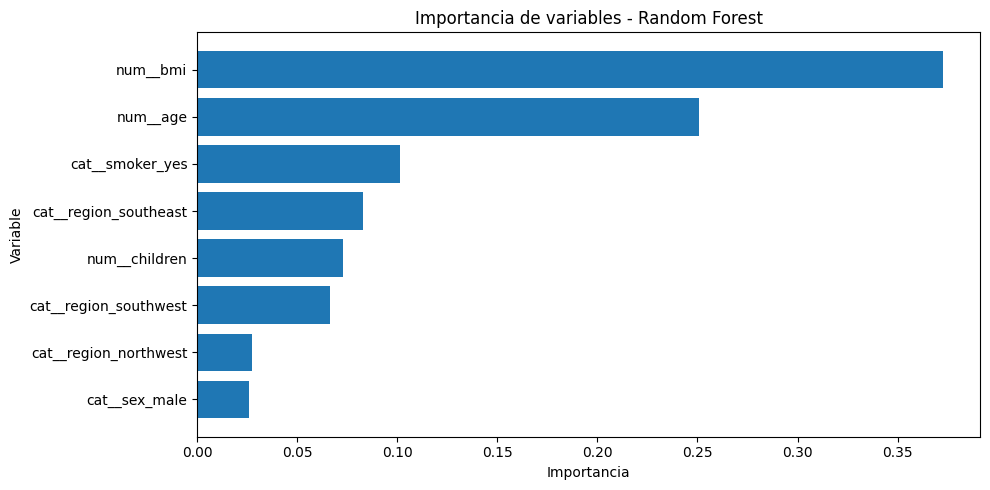

In [63]:
# ===================================== #
# 53. GRÁFICO DE IMPORTANCIA RF          #
# ===================================== #

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.barh(rf_importance["Variable"], rf_importance["Importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de variables - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Análisis de interpretabilidad

En el modelo Ridge, los coeficientes permiten analizar la dirección y magnitud del efecto de cada variable transformada sobre la variable objetivo.

Un coeficiente positivo indica que, al aumentar esa variable, los cargos médicos tienden a aumentar.  
Un coeficiente negativo indica que, al aumentar esa variable, los cargos médicos tienden a disminuir.

En Random Forest, la importancia de variables permite identificar cuáles variables aportan más a la predicción del modelo.

Estas interpretaciones deben hacerse teniendo en cuenta que las variables numéricas fueron escaladas y las variables categóricas fueron codificadas mediante One Hot Encoding.

## 9. Análisis de Residuos

En esta sección se analizan los residuos del mejor modelo seleccionado.

Los residuos se calculan como:

Valor real - Valor predicho

Este análisis permite revisar si existen patrones no aleatorios, problemas de homocedasticidad o errores sistemáticos en las predicciones.

In [64]:
# ===================================== #
# 54. CÁLCULO DE RESIDUOS                #
# ===================================== #

y_pred = best_model.predict(X_test)

residuos = y_test - y_pred

residuos.head()

764     2.890547e+11
887    -4.348803e+11
890     1.537421e+12
1293    2.866754e+11
259    -6.861833e+11
Name: charges, dtype: float64

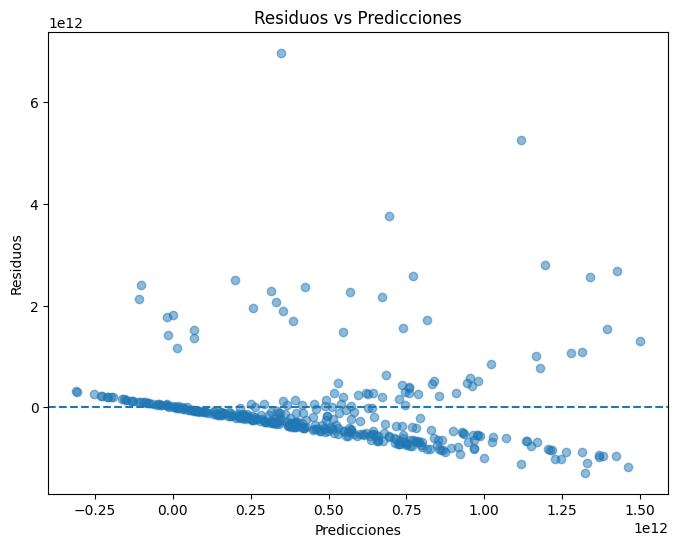

In [65]:
# ===================================== #
# 55. RESIDUOS VS PREDICCIONES           #
# ===================================== #

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuos, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos vs Predicciones")

plt.show()

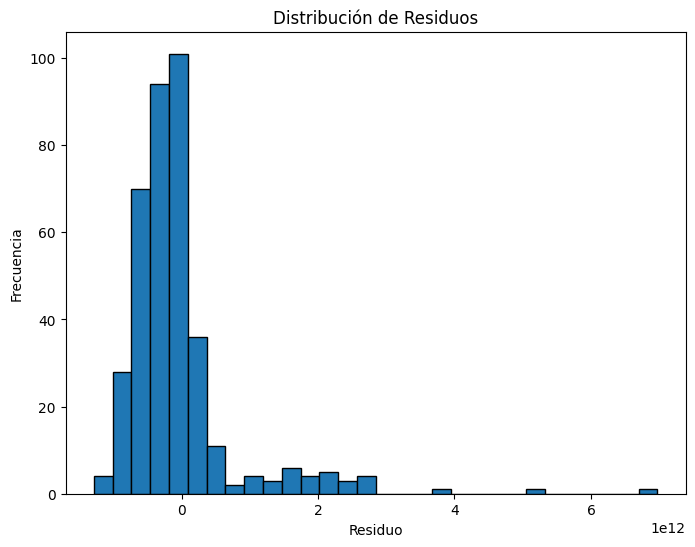

In [66]:
# ===================================== #
# 56. DISTRIBUCIÓN DE RESIDUOS           #
# ===================================== #

plt.figure(figsize=(8, 6))
plt.hist(residuos, bins=30, edgecolor="black")

plt.title("Distribución de Residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")

plt.show()

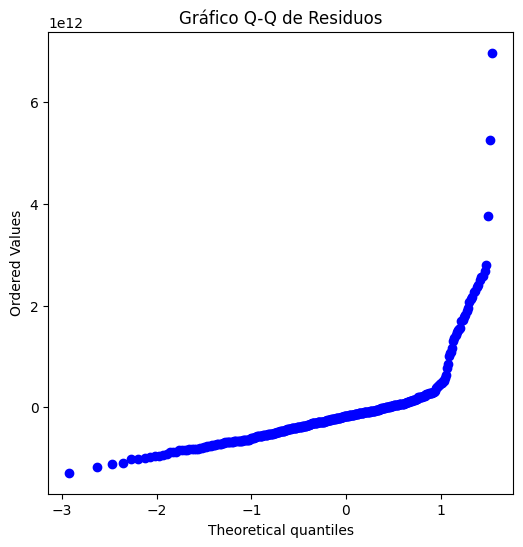

In [67]:
# ===================================== #
# 57. GRÁFICO Q-Q DE RESIDUOS            #
# ===================================== #

import scipy.stats as stats

plt.figure(figsize=(6, 6))
stats.probplot(residuos, dist="norm", plot=plt)

plt.title("Gráfico Q-Q de Residuos")
plt.show()

In [68]:
# ===================================== #
# 58. ESTADÍSTICAS DE RESIDUOS           #
# ===================================== #

resumen_residuos = pd.DataFrame({
    "Métrica": [
        "Media de residuos",
        "Desviación estándar",
        "Residuo mínimo",
        "Residuo máximo"
    ],
    "Valor": [
        residuos.mean(),
        residuos.std(),
        residuos.min(),
        residuos.max()
    ]
})

resumen_residuos

,Métrica,Valor
0,Media de residuos,-5.623992e+10
1,Desviación estándar,8.409475e+11
2,Residuo mínimo,-1.285285e+12
3,Residuo máximo,6.975071e+12


## Análisis de residuos

El gráfico de residuos vs predicciones permite evaluar si los errores se distribuyen de manera aleatoria alrededor de cero.

Si los puntos se distribuyen sin un patrón claro, esto indica un comportamiento adecuado del modelo.  
Si aparece una forma de embudo, puede existir heterocedasticidad.  
Si aparece una curva o patrón sistemático, puede indicar que el modelo no está capturando completamente la relación entre las variables.

La distribución de residuos y el gráfico Q-Q permiten revisar si los errores se aproximan a una distribución normal.

En problemas reales de costos médicos es común encontrar algunos valores extremos, ya que ciertos individuos pueden tener cargos médicos muy altos.

## 10. Selección del Modelo Final

La selección del modelo final se realiza considerando:

- Métricas en validación cruzada.
- Desempeño en el conjunto de prueba.
- Interpretabilidad del modelo.
- Análisis de residuos.

El modelo final debe tener buen desempeño predictivo y una capacidad razonable de generalización.

In [69]:
# ===================================== #
# 59. TABLA FINAL COMPARATIVA            #
# ===================================== #

final_model_summary = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R2"],
    "CV promedio": [
        cv_metrics["MAE_mean"],
        cv_metrics["RMSE_mean"],
        cv_metrics["R2_mean"]
    ],
    "Test Hold-Out": [
        test_mae,
        test_rmse,
        test_r2
    ]
})

final_model_summary.round(4)

,Métrica,CV promedio,Test Hold-Out
0,MAE,5.542479e+11,5.103738e+11
1,RMSE,8.753029e+11,8.417154e+11
2,R2,1.366000e-01,6.880000e-02


In [70]:
# ===================================== #
# 60. DIAGNÓSTICO DE GENERALIZACIÓN      #
# ===================================== #

print("Modelo final candidato:", best_model_name)

diferencia_r2 = cv_metrics["R2_mean"] - test_r2

print("\nR2 en CV:", cv_metrics["R2_mean"])
print("R2 en Test:", test_r2)
print("Diferencia R2 CV - Test:", diferencia_r2)

if diferencia_r2 > 0.10:
    print("\nPosible sobreajuste: el modelo rinde mejor en CV que en test.")
elif diferencia_r2 < -0.10:
    print("\nEl modelo rindió mejor en test que en CV. Puede deberse a la partición de los datos.")
else:
    print("\nEl modelo muestra un comportamiento razonablemente estable entre CV y test.")

Modelo final candidato: Ridge ajustado

R2 en CV: 0.13657036572158202
R2 en Test: 0.06877381485179179
Diferencia R2 CV - Test: 0.06779655086979022

El modelo muestra un comportamiento razonablemente estable entre CV y test.


In [71]:
# ===================================== #
# 61. DEFINICIÓN DEL MODELO FINAL        #
# ===================================== #

final_model = best_model
final_model_name = best_model_name

print("Modelo final seleccionado:")
print(final_model_name)

Modelo final seleccionado:
Ridge ajustado


## Conclusión sobre el modelo final

El modelo final seleccionado fue el modelo con mejor desempeño después del ajuste de hiperparámetros, considerando principalmente el RMSE en validación cruzada y su comportamiento en el conjunto de prueba.

La decisión no se basó únicamente en una métrica, sino en la comparación entre validación cruzada, evaluación hold-out, interpretabilidad y análisis de residuos.

Si el desempeño en test es similar al desempeño obtenido en validación cruzada, se concluye que el modelo tiene una capacidad de generalización adecuada.

El modelo final será utilizado posteriormente para el guardado del modelo y de las variables procesadas.

In [72]:
# ===================================== #
# 33. GUARDAR MODELO                    #
# ===================================== #

import os
import joblib

# ===================================== #
# GUARDAR MEJOR MODELO                  #
# ===================================== #

joblib.dump(
    best_model,
    "models/model_regresion.joblib"
)

print("Modelo guardado correctamente")

# ===================================== #
# GUARDAR FEATURES                      #
# ===================================== #

features = X.columns.tolist()

joblib.dump(
    features,
    "models/features_regresion.joblib"
)

print("Features guardadas correctamente")

Modelo guardado correctamente
Features guardadas correctamente


In [73]:
# ===================================== #
# VERIFICAR MODELO GUARDADO             #
# ===================================== #

import joblib

modelo = joblib.load(
    "models/model_regresion.joblib"
)

print(modelo)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', Ridge(alpha=10, random_state=42))])


In [74]:
features = joblib.load(
    "models/features_regresion.joblib"
)

print(features)

['age', 'sex', 'bmi', 'children', 'smoker', 'region']


In [75]:
import os

print(os.getcwd())

c:\Users\Lenovo ThinkBook\Downloads\ml-project_analitica_datos\notebooks


In [76]:
import os
import joblib

ruta_actual = os.getcwd()

ruta_models = os.path.join(
    ruta_actual,
    "models"
)

os.makedirs(ruta_models, exist_ok=True)

joblib.dump(
    mejor_modelo,
    os.path.join(
        ruta_models,
        "model_classification.joblib"
    )
)

print("Modelo guardado correctamente")

Modelo guardado correctamente
